# ABC Supermarket Campaign Analysis

This notebook explores the results of the previous gold-membership campaign. The goal is to understand the data and identify factors that may help predict whether a customer will accept the offer.

## 1. Import libraries and load the dataset

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
PLOT_COLOR = "steelblue"
pd.set_option("display.max_columns", 30)

In [2]:
data_path = Path("data/marketing_data.xlsx")

if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

df = pd.read_excel(data_path, sheet_name="marketing_data")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2240, 22)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,2014-11-05 00:00:00,0,10,0,1,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,2014-08-04 00:00:00,0,6,16,24,11,0,34,2,3,1,2,7,1,0


## 2. Overview of the data

Each row represents one customer. `Response` is the target variable: 1 means the customer accepted the previous offer and 0 means the customer did not.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
missing_values = df.isnull().sum()
unique_values = df.nunique()

column_overview = pd.DataFrame({
    "Data type": df.dtypes,
    "Missing values": missing_values,
    "Unique values": unique_values,
})

display(column_overview)

,Data type,Missing values,Unique values
ID,int64,0,2240
Year_Birth,int64,0,59
Education,object,0,5
Marital_Status,object,0,8
Income,float64,24,1974
Kidhome,int64,0,3
Teenhome,int64,0,3
Dt_Customer,object,0,663
Recency,int64,0,100
MntWines,int64,0,776


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["ID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [6]:
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


In [7]:
print("Education")
display(df["Education"].value_counts().to_frame("Customers"))

print("Marital status")
display(df["Marital_Status"].value_counts().to_frame("Customers"))

Education


,Customers
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


Marital status


,Customers
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
YOLO,2
Absurd,2


### Basic data-quality checks

A separate DataFrame is used for exploration so the original data remains unchanged. A few simple features are also created to make customer behavior easier to interpret.

In [8]:
eda = df.copy()
eda["Dt_Customer"] = pd.to_datetime(eda["Dt_Customer"], format="mixed", errors="coerce")

spend_columns = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
purchase_columns = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

latest_date = eda["Dt_Customer"].max()
eda["Age"] = latest_date.year - eda["Year_Birth"]
eda["Children"] = eda["Kidhome"] + eda["Teenhome"]
eda["Total_Spend"] = eda[spend_columns].sum(axis=1)
eda["Total_Purchases"] = eda[purchase_columns].sum(axis=1)
eda["Customer_Tenure_Days"] = (latest_date - eda["Dt_Customer"]).dt.days

print("Missing income values:", eda["Income"].isnull().sum())
print("Unparsed dates:", eda["Dt_Customer"].isnull().sum())
print("Customers older than 100:", (eda["Age"] > 100).sum())
print("Income above 200,000:", (eda["Income"] > 200000).sum())
print("Enrollment dates:", eda["Dt_Customer"].min().date(), "to", latest_date.date())

Missing income values: 24
Unparsed dates: 0
Customers older than 100: 3
Income above 200,000: 1
Enrollment dates: 2012-01-08 to 2014-12-06


The dataset has missing income values and a few extreme age and income observations. These will be handled later during data preparation.

## 3. Data visualization and EDA

The charts below compare customer characteristics with the historical campaign response. These are descriptive relationships and do not prove causation.

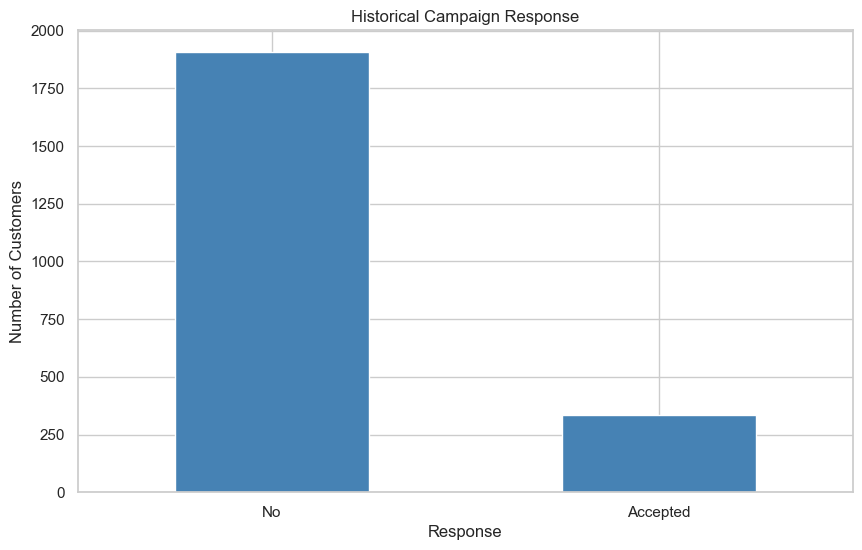

Response rate: 14.9 %


In [9]:
response_counts = eda["Response"].value_counts().sort_index()

response_counts.plot(kind="bar", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Historical Campaign Response")
plt.xlabel("Response")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No", "Accepted"], rotation=0)
plt.show()

print("Response rate:", round(eda["Response"].mean() * 100, 1), "%")

Only 14.9% of customers accepted the offer. Because the target is imbalanced, accuracy should not be the only model metric used later.

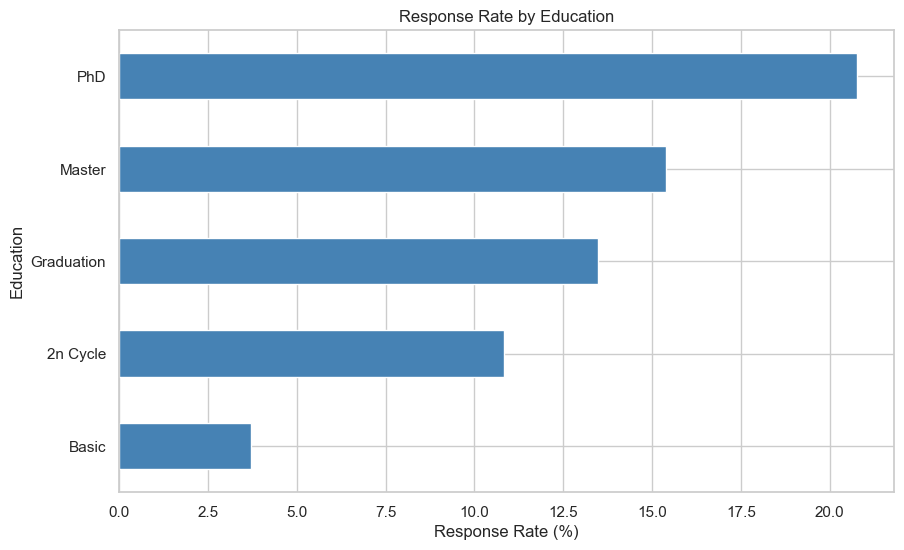

In [10]:
education_response = eda.groupby("Education")["Response"].mean().sort_values() * 100

education_response.plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Response Rate by Education")
plt.xlabel("Response Rate (%)")
plt.ylabel("Education")
plt.show()

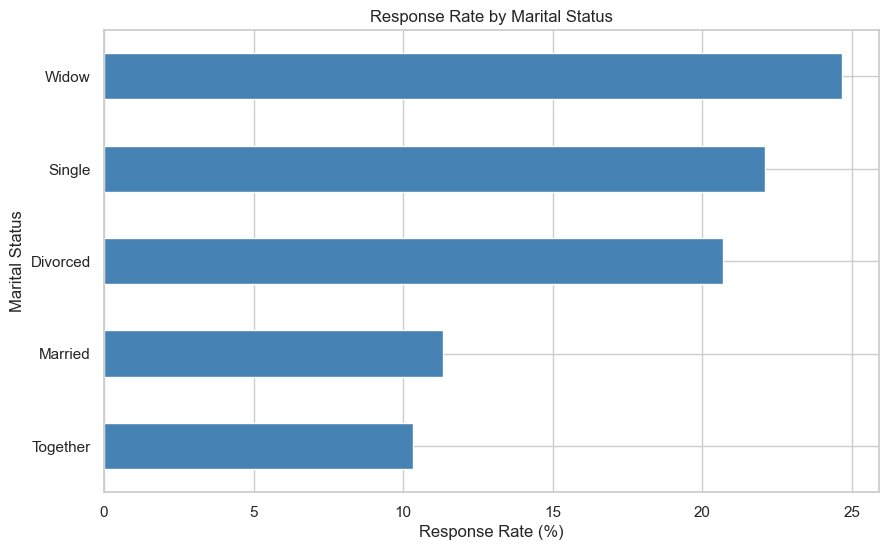

In [11]:
marital_summary = eda.groupby("Marital_Status")["Response"].agg(["mean", "count"])
marital_summary = marital_summary[marital_summary["count"] >= 20]
marital_response = marital_summary["mean"].sort_values() * 100

marital_response.plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Response Rate by Marital Status")
plt.xlabel("Response Rate (%)")
plt.ylabel("Marital Status")
plt.show()

Marital groups with fewer than 20 customers are excluded because their response rates are based on very small samples.

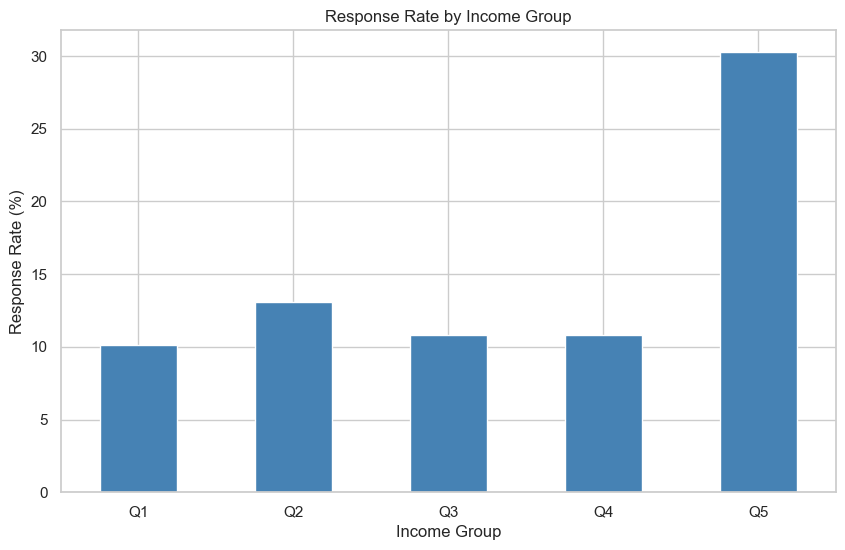

In [12]:
eda["Income_Group"] = pd.qcut(eda["Income"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
income_response = eda.groupby("Income_Group", observed=True)["Response"].mean() * 100

income_response.plot(kind="bar", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Response Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=0)
plt.show()

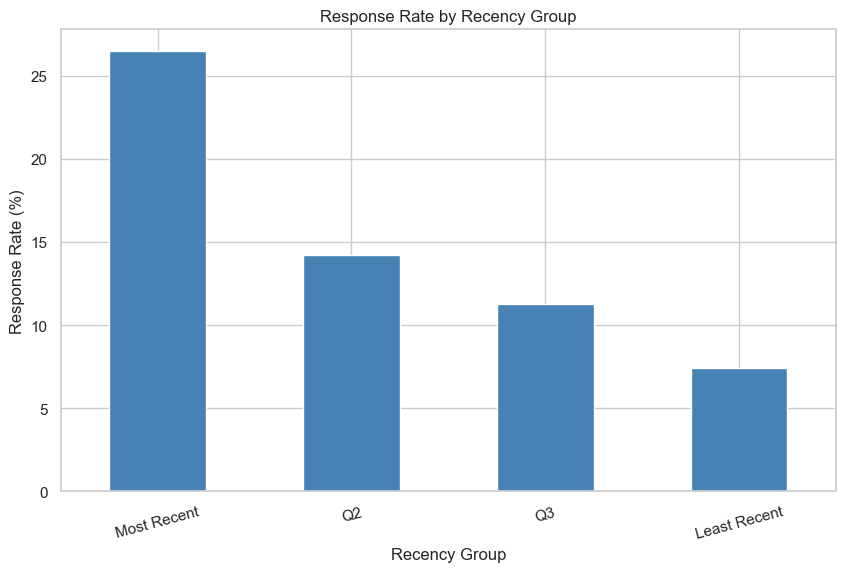

In [13]:
eda["Recency_Group"] = pd.qcut(eda["Recency"], 4, labels=["Most Recent", "Q2", "Q3", "Least Recent"])
recency_response = eda.groupby("Recency_Group", observed=True)["Response"].mean() * 100

recency_response.plot(kind="bar", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Response Rate by Recency Group")
plt.xlabel("Recency Group")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=15)
plt.show()

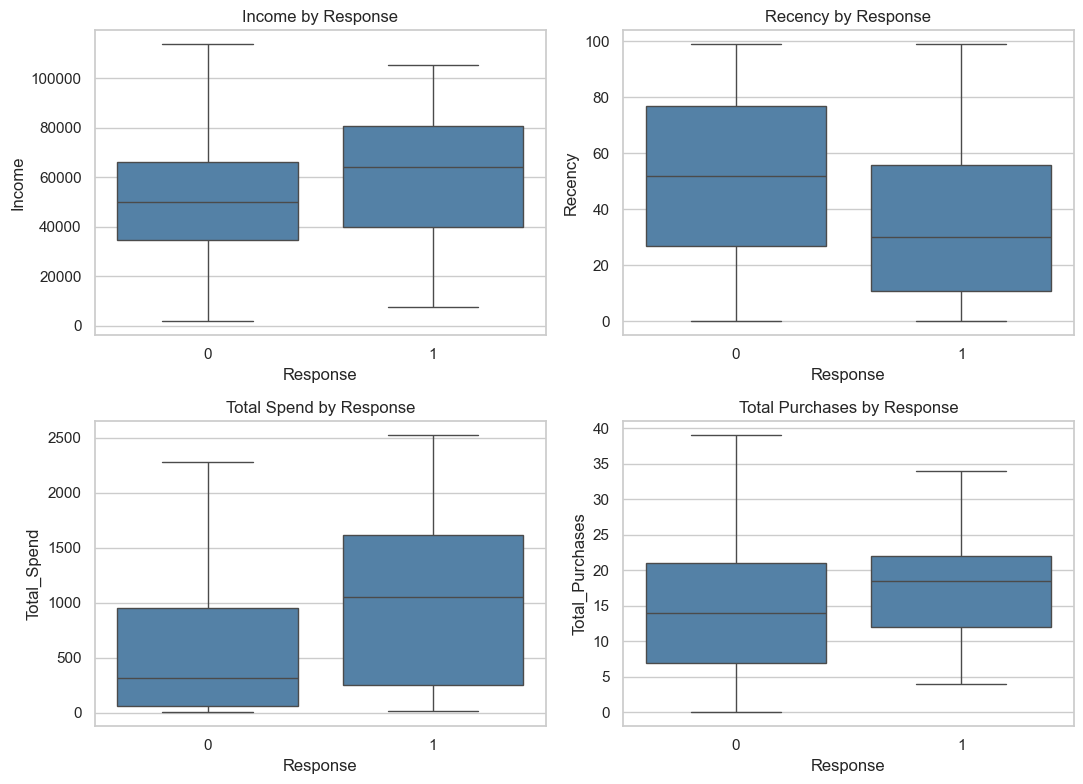

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.boxplot(data=eda, x="Response", y="Income", color=PLOT_COLOR, showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title("Income by Response")

sns.boxplot(data=eda, x="Response", y="Recency", color=PLOT_COLOR, showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Recency by Response")

sns.boxplot(data=eda, x="Response", y="Total_Spend", color=PLOT_COLOR, showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Total Spend by Response")

sns.boxplot(data=eda, x="Response", y="Total_Purchases", color=PLOT_COLOR, showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title("Total Purchases by Response")

plt.tight_layout()
plt.show()

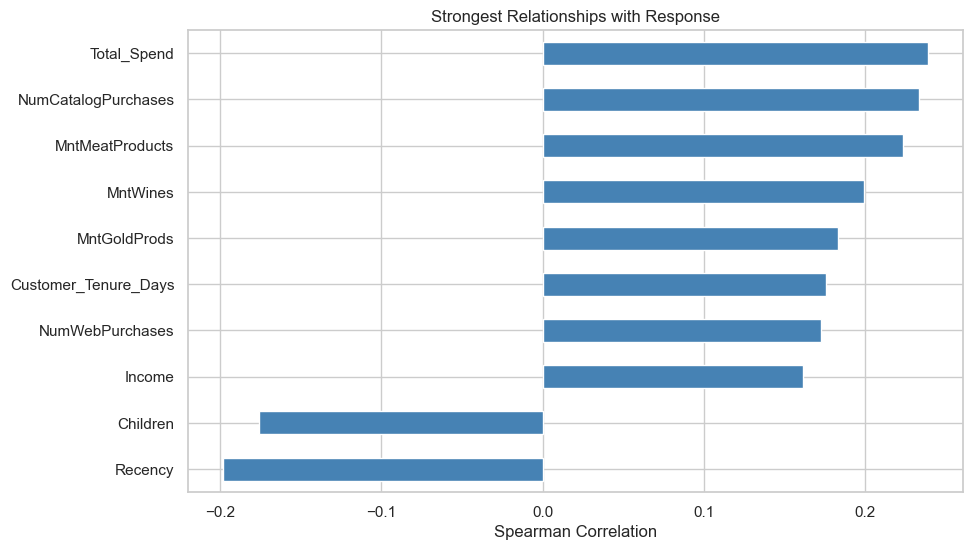

In [15]:
features = [
    "Income", "Age", "Children", "Recency", "Customer_Tenure_Days", "Total_Spend", "Total_Purchases",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Complain",
]

correlations = eda[features + ["Response"]].corr(method="spearman")["Response"]
correlations = correlations.drop("Response")
top_correlations = correlations.loc[correlations.abs().sort_values().tail(10).index].sort_values()

top_correlations.plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Strongest Relationships with Response")
plt.xlabel("Spearman Correlation")
plt.ylabel("")
plt.show()

### Initial findings

- Customers with higher spending, more catalog purchases, higher income, and longer tenure generally responded more often.
- Customers who purchased more recently had a noticeably higher response rate.
- Responders tended to have fewer children and greater purchase activity.
- Missing income values, extreme observations, rare categories, and target imbalance should be addressed during data preparation.

These findings will guide feature preparation and model selection in the next part of the analysis.

## 4. Data preparation

The following steps prepare the data for modeling:

- Remove the customer ID because it is only an identifier.
- Convert birth year and enrollment date into age and customer tenure.
- Remove four clearly extreme age or income observations.
- Group very small marital-status categories.
- Split the data before fitting the imputer, scaler, and encoder to prevent data leakage.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [17]:
model_data = df.copy()
model_data["Dt_Customer"] = pd.to_datetime(model_data["Dt_Customer"], format="mixed", errors="coerce")

reference_date = pd.Timestamp("2014-12-31")
model_data["Age"] = reference_date.year - model_data["Year_Birth"]
model_data["Customer_Tenure_Days"] = (reference_date - model_data["Dt_Customer"]).dt.days

starting_rows = len(model_data)
model_data = model_data[model_data["Age"] <= 100].copy()
model_data = model_data[(model_data["Income"] <= 200000) | model_data["Income"].isnull()].copy()

model_data["Marital_Status"] = model_data["Marital_Status"].replace({
    "Alone": "Single",
    "Absurd": "Other",
    "YOLO": "Other",
})

print("Rows before removing extreme values:", starting_rows)
print("Rows available for modeling:", len(model_data))

Rows before removing extreme values: 2240
Rows available for modeling: 2236


In [18]:
columns_to_drop = ["Response", "ID", "Year_Birth", "Dt_Customer"]

X = model_data.drop(columns=columns_to_drop)
y = model_data["Response"]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Target response rate:", round(y.mean() * 100, 1), "%")

Numeric features: 18
Categorical features: ['Education', 'Marital_Status']
Target response rate: 14.9 %


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 1788
Test rows: 448


The preprocessing pipeline learns all replacement and scaling values from the training set only. Numeric columns use median imputation and standardization. Categorical columns use one-hot encoding.

In [20]:
numeric_preparation = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preparation = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preparation, numeric_features),
    ("categorical", categorical_preparation, categorical_features),
])

## 5. Train and compare several models

The models represent different levels of complexity. A dummy model is included to show what happens when every customer is predicted as the majority class.

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [22]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=1),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

In [23]:
results = []
trained_models = {}

for model_name, model in models.items():
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    model_pipeline.fit(X_train, y_train)
    predictions = model_pipeline.predict(X_test)
    probabilities = model_pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "PR AUC": average_precision_score(y_test, probabilities),
    })

    trained_models[model_name] = model_pipeline

model_results = pd.DataFrame(results).set_index("Model")
model_results = model_results.sort_values("PR AUC", ascending=False)
display(model_results.round(3))

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Model,,,,,,
Logistic Regression,0.812,0.427,0.746,0.543,0.883,0.624
Gradient Boosting,0.886,0.722,0.388,0.505,0.891,0.615
Random Forest,0.862,0.600,0.224,0.326,0.889,0.542
Decision Tree,0.717,0.319,0.791,0.455,0.785,0.437
KNN,0.859,0.600,0.179,0.276,0.774,0.376
Dummy,0.850,0.000,0.000,0.000,0.500,0.150


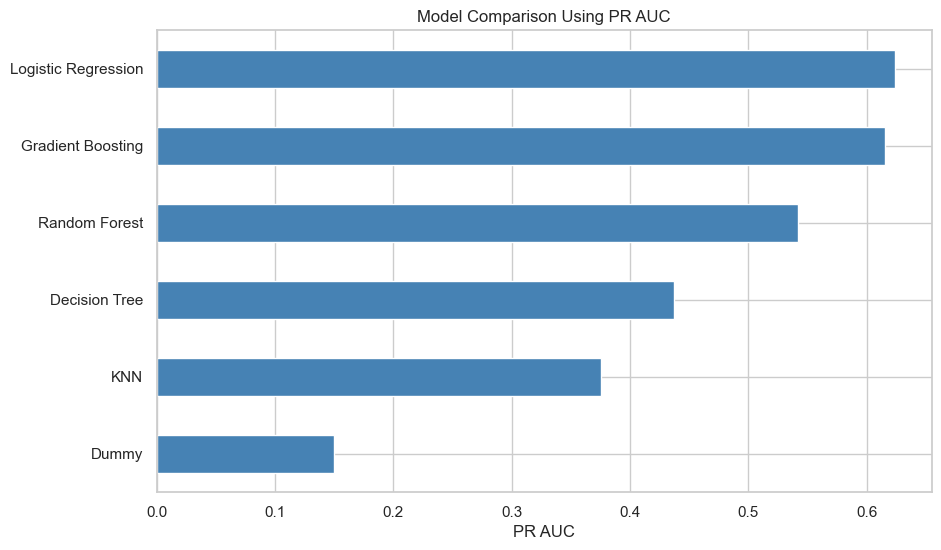

In [24]:
model_results["PR AUC"].sort_values().plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Model Comparison Using PR AUC")
plt.xlabel("PR AUC")
plt.ylabel("")
plt.show()

### Comments on the initial model results

- **Dummy model:** Its accuracy is about 85%, but recall and F1 are zero because it predicts every customer as a non-responder. This shows why accuracy is misleading for this dataset.
- **Logistic regression:** It has the highest initial PR AUC and a strong balance between recall and precision. Its higher recall is useful when the business wants to avoid missing likely responders.
- **Gradient boosting:** It has the highest accuracy, precision, and ROC AUC. It may be more useful for a selective campaign where the business wants fewer, higher-quality calls.
- **Random forest:** Its ROC AUC is competitive, but recall is low at the default 0.50 threshold. It ranks customers well but is conservative when assigning the positive class.
- **Decision tree:** It finds many responders, but its low precision means it also produces many false-positive calls.
- **KNN:** It misses most responders because nearby observations are often dominated by the larger non-response class.

No model is the final winner yet. Logistic regression, random forest, and gradient boosting will move to hyperparameter tuning because they provide the strongest probability rankings and different precision-recall tradeoffs.

## 6. Hyperparameter tuning

The top three models are tuned using five-fold stratified cross-validation. PR AUC is used as the search score because the target is imbalanced and the model needs to rank likely responders well.

A small grid is used for each model so the search remains practical and easy to explain. The test set is not used during the searches.

In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight

cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Logistic regression tuning

`C` controls the amount of regularization. The search also checks whether balanced class weights improve the model.

In [26]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

logistic_parameters = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_parameters,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
)

logistic_search.fit(X_train, y_train)
print("Best parameters:", logistic_search.best_params_)
print("Best CV PR AUC:", round(logistic_search.best_score_, 3))

Best parameters: {'model__C': 1, 'model__class_weight': 'balanced'}
Best CV PR AUC: 0.479


### Random forest tuning

The search adjusts the number and depth of trees and the minimum number of observations allowed in each leaf.

In [27]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=1)),
])

forest_parameters = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_leaf": [1, 4],
    "model__class_weight": ["balanced"],
}

forest_search = GridSearchCV(
    forest_pipeline,
    forest_parameters,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
)

forest_search.fit(X_train, y_train)
print("Best parameters:", forest_search.best_params_)
print("Best CV PR AUC:", round(forest_search.best_score_, 3))

Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
Best CV PR AUC: 0.509


### Gradient boosting tuning

The search adjusts the number of trees, learning rate, tree depth, and minimum leaf size. Balanced sample weights are used because this model does not have a `class_weight` option.

In [28]:
boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42, subsample=0.85)),
])

boosting_parameters = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 5],
}

boosting_search = GridSearchCV(
    boosting_pipeline,
    boosting_parameters,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
)

boosting_weights = compute_sample_weight(class_weight="balanced", y=y_train)
boosting_search.fit(X_train, y_train, model__sample_weight=boosting_weights)
print("Best parameters:", boosting_search.best_params_)
print("Best CV PR AUC:", round(boosting_search.best_score_, 3))

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 150}
Best CV PR AUC: 0.538


### Tuned model comparison

The selected version of each model is now evaluated on the untouched test set. The cross-validation PR AUC is included to show how each model performed during tuning.

In [29]:
tuned_searches = {
    "Logistic Regression": logistic_search,
    "Random Forest": forest_search,
    "Gradient Boosting": boosting_search,
}

tuned_results = []

for model_name, search in tuned_searches.items():
    predictions = search.predict(X_test)
    probabilities = search.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": model_name,
        "CV PR AUC": search.best_score_,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "Test PR AUC": average_precision_score(y_test, probabilities),
    })

tuned_model_results = pd.DataFrame(tuned_results).set_index("Model")
display(tuned_model_results.round(3))

,CV PR AUC,Accuracy,Precision,Recall,F1 Score,ROC AUC,Test PR AUC
Model,,,,,,,
Logistic Regression,0.479,0.812,0.427,0.746,0.543,0.883,0.624
Random Forest,0.509,0.871,0.576,0.507,0.540,0.890,0.553
Gradient Boosting,0.538,0.850,0.500,0.806,0.617,0.899,0.589


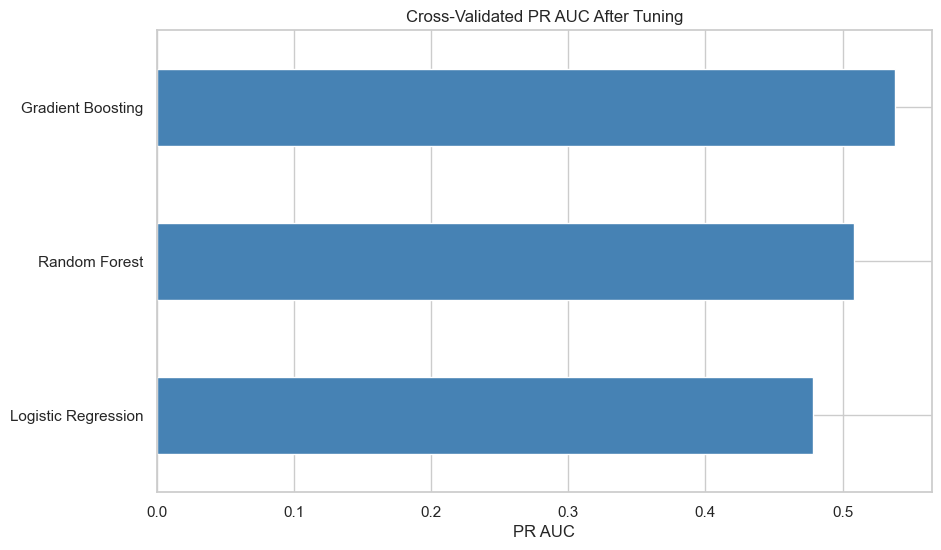

In [30]:
tuned_model_results["CV PR AUC"].sort_values().plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Cross-Validated PR AUC After Tuning")
plt.xlabel("PR AUC")
plt.ylabel("")
plt.show()

### Tuning results

- **Gradient boosting** has the highest cross-validated PR AUC. With balanced sample weights, it also has the highest test recall, F1 score, and ROC AUC among the tuned models.
- **Logistic regression** still has the highest test PR AUC and provides a simpler, more interpretable benchmark.
- **Random forest** becomes more balanced after tuning. Its recall improves substantially compared with the initial model while maintaining reasonable precision.

Gradient boosting is the strongest tuned candidate overall, but the final choice should still consider the number of customers ABC can call and the financial cost of false-positive and false-negative predictions. Classification-threshold selection can be used next to match the model to that business constraint.

## 7. Explore additional ensemble models

Three ensemble approaches are compared with the tuned gradient boosting model:

- **Extra Trees:** Builds many highly randomized decision trees.
- **Soft voting:** Averages the probabilities from logistic regression, random forest, and gradient boosting.
- **Stacking:** Uses the three models as inputs to a final logistic regression model.

The same preprocessing, balanced sample weights, and five-fold cross-validation are used for a fair comparison.

In [31]:
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score

best_logistic_model = clone(logistic_search.best_estimator_.named_steps["model"])
best_forest_model = clone(forest_search.best_estimator_.named_steps["model"])
best_boosting_model = clone(boosting_search.best_estimator_.named_steps["model"])

best_logistic_model.set_params(class_weight=None)
best_forest_model.set_params(class_weight=None)

base_estimators = [
    ("logistic", best_logistic_model),
    ("forest", best_forest_model),
    ("boosting", best_boosting_model),
]

### Extra Trees

In [32]:
extra_trees_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=1)),
])

extra_trees_cv = cross_val_score(
    extra_trees_pipeline,
    X_train,
    y_train,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
    params={"model__sample_weight": boosting_weights},
)

extra_trees_pipeline.fit(X_train, y_train, model__sample_weight=boosting_weights)
print("Mean CV PR AUC:", round(extra_trees_cv.mean(), 3))

Mean CV PR AUC: 0.482


### Soft voting

Soft voting combines the three tuned models by averaging their predicted probabilities.

In [33]:
voting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(estimators=base_estimators, voting="soft")),
])

voting_cv = cross_val_score(
    voting_pipeline,
    X_train,
    y_train,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
    params={"model__sample_weight": boosting_weights},
)

voting_pipeline.fit(X_train, y_train, model__sample_weight=boosting_weights)
print("Mean CV PR AUC:", round(voting_cv.mean(), 3))

Mean CV PR AUC: 0.549


### Stacking

Stacking allows a final logistic regression model to learn how to combine the three base models.

In [34]:
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=1,
)

stacking_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking_model),
])

stacking_cv = cross_val_score(
    stacking_pipeline,
    X_train,
    y_train,
    scoring="average_precision",
    cv=cross_validation,
    n_jobs=1,
    params={"model__sample_weight": boosting_weights},
)

stacking_pipeline.fit(X_train, y_train, model__sample_weight=boosting_weights)
print("Mean CV PR AUC:", round(stacking_cv.mean(), 3))

Mean CV PR AUC: 0.545


### Ensemble comparison

In [35]:
ensemble_models = {
    "Extra Trees": extra_trees_pipeline,
    "Soft Voting": voting_pipeline,
    "Stacking": stacking_pipeline,
}

ensemble_cv_scores = {
    "Extra Trees": extra_trees_cv.mean(),
    "Soft Voting": voting_cv.mean(),
    "Stacking": stacking_cv.mean(),
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    ensemble_results.append({
        "Model": model_name,
        "CV PR AUC": ensemble_cv_scores[model_name],
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "Test PR AUC": average_precision_score(y_test, probabilities),
    })

ensemble_model_results = pd.DataFrame(ensemble_results).set_index("Model")
display(ensemble_model_results.round(3))

,CV PR AUC,Accuracy,Precision,Recall,F1 Score,ROC AUC,Test PR AUC
Model,,,,,,,
Extra Trees,0.482,0.884,0.647,0.493,0.559,0.897,0.604
Soft Voting,0.549,0.866,0.537,0.761,0.630,0.907,0.624
Stacking,0.545,0.826,0.457,0.866,0.598,0.907,0.616


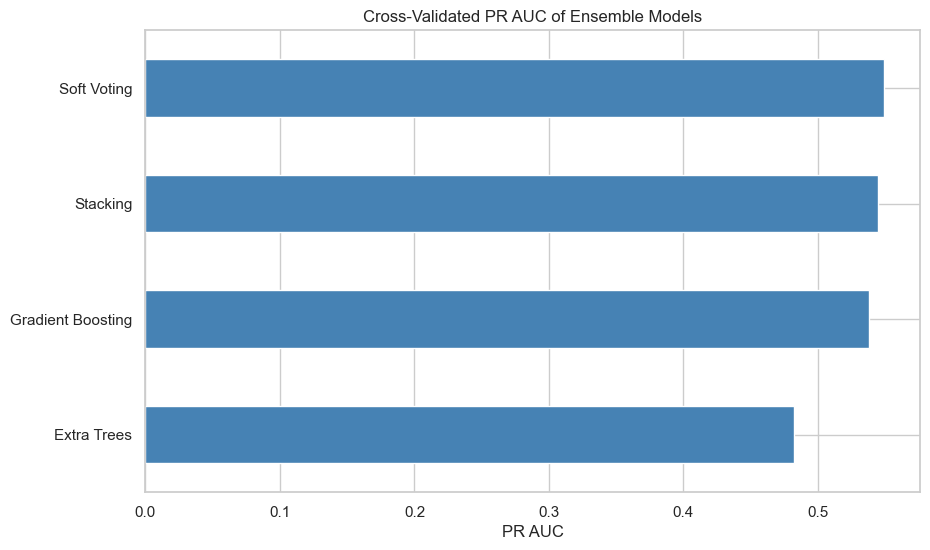

In [36]:
ensemble_comparison = pd.Series({
    "Gradient Boosting": boosting_search.best_score_,
    "Extra Trees": extra_trees_cv.mean(),
    "Soft Voting": voting_cv.mean(),
    "Stacking": stacking_cv.mean(),
})

ensemble_comparison.sort_values().plot(kind="barh", color=PLOT_COLOR, figsize=(10, 6))
plt.title("Cross-Validated PR AUC of Ensemble Models")
plt.xlabel("PR AUC")
plt.ylabel("")
plt.show()

### Ensemble findings

- **Soft voting** has the highest cross-validated PR AUC. It also improves test F1 and ROC AUC while retaining strong recall.
- **Stacking** finds the largest percentage of responders, but its lower precision would lead to more unsuccessful calls.
- **Extra Trees** has the highest precision among the new ensembles, but it misses more responders.

Soft voting provides the best overall balance for this campaign. It becomes the preferred final model, while gradient boosting remains an important component of the ensemble.

## 8. Classification model visualizations

The following charts evaluate the final soft-voting model at the default classification threshold of 0.50. The probability-based campaign ranking remains more flexible because the threshold can later be adjusted to match call capacity.

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

voting_predictions = voting_pipeline.predict(X_test)
voting_probabilities = voting_pipeline.predict_proba(X_test)[:, 1]

### Confusion matrix

The confusion matrix shows the number of correct and incorrect classifications for responders and non-responders.

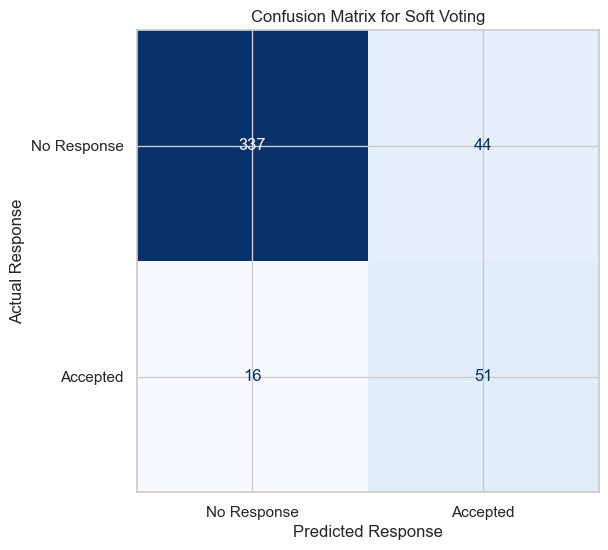

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    voting_predictions,
    display_labels=["No Response", "Accepted"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

plt.title("Confusion Matrix for Soft Voting")
plt.xlabel("Predicted Response")
plt.ylabel("Actual Response")
plt.show()

At the 0.50 threshold, the model correctly identifies 51 of the 67 responders and misses 16. It also identifies 337 non-responders correctly, while 44 non-responders would receive unnecessary calls.

### ROC curve

The ROC curve shows the model's ability to separate responders from non-responders across different thresholds.

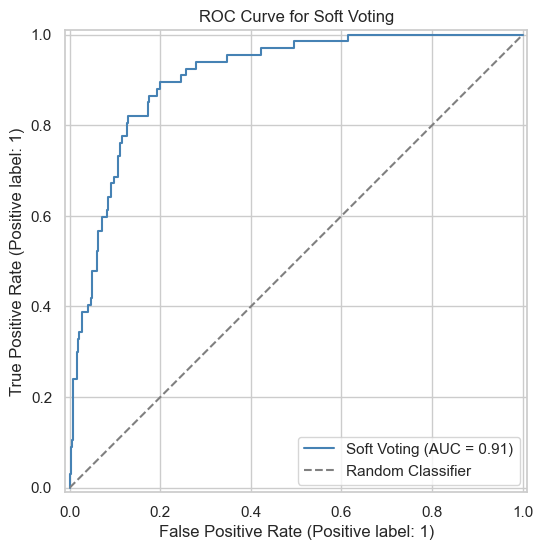

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

RocCurveDisplay.from_predictions(
    y_test,
    voting_probabilities,
    name="Soft Voting",
    color=PLOT_COLOR,
    ax=ax,
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.title("ROC Curve for Soft Voting")
plt.legend()
plt.show()

The ROC AUC is 0.907. This means the model has strong overall ability to rank a randomly chosen responder above a randomly chosen non-responder.

### Precision-recall curve

The precision-recall curve focuses on the positive class and is especially useful because responders represent only about 15% of the data.

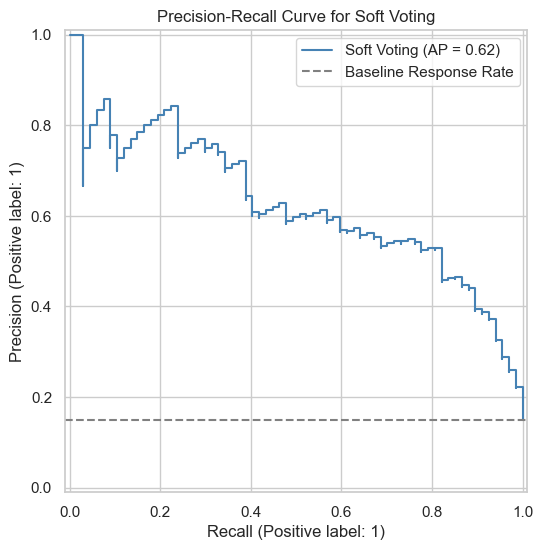

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    voting_probabilities,
    name="Soft Voting",
    color=PLOT_COLOR,
    ax=ax,
)

plt.axhline(y=y_test.mean(), linestyle="--", color="gray", label="Baseline Response Rate")
plt.title("Precision-Recall Curve for Soft Voting")
plt.legend()
plt.show()

The test PR AUC is 0.624, which is substantially higher than the baseline response rate of approximately 0.15. The curve also shows the tradeoff between finding more responders and limiting unsuccessful calls as the threshold changes.

## 9. Business recommendations

The soft-voting ensemble is selected because it has the highest cross-validated PR AUC and improves the balance between recall and precision compared with gradient boosting alone.

Rather than applying only the default 0.50 threshold, ABC can rank customers by predicted probability and choose how many customers to call based on campaign capacity.

In [41]:
final_model = voting_pipeline

campaign_results = pd.DataFrame({
    "Actual_Response": y_test.to_numpy(),
    "Predicted_Probability": final_model.predict_proba(X_test)[:, 1],
})

campaign_results = campaign_results.sort_values("Predicted_Probability", ascending=False).reset_index(drop=True)
baseline_response_rate = campaign_results["Actual_Response"].mean()
total_responders = campaign_results["Actual_Response"].sum()

In [42]:
campaign_summary = []

for contact_rate in [0.10, 0.20, 0.30, 0.40, 0.50]:
    customers_called = round(len(campaign_results) * contact_rate)
    selected_customers = campaign_results.head(customers_called)
    responders_found = selected_customers["Actual_Response"].sum()
    response_rate = selected_customers["Actual_Response"].mean()

    campaign_summary.append({
        "Customers Contacted (%)": contact_rate * 100,
        "Customers Called": customers_called,
        "Responders Found": responders_found,
        "Responders Captured (%)": responders_found / total_responders * 100,
        "Response Rate (%)": response_rate * 100,
        "Lift": response_rate / baseline_response_rate,
    })

campaign_summary = pd.DataFrame(campaign_summary)
display(campaign_summary.round(2))

,Customers Contacted (%),Customers Called,Responders Found,Responders Captured (%),Response Rate (%),Lift
0,10.0,45,27,40.30,60.00,4.01
1,20.0,90,49,73.13,54.44,3.64
2,30.0,134,59,88.06,44.03,2.94
3,40.0,179,63,94.03,35.20,2.35
4,50.0,224,64,95.52,28.57,1.91


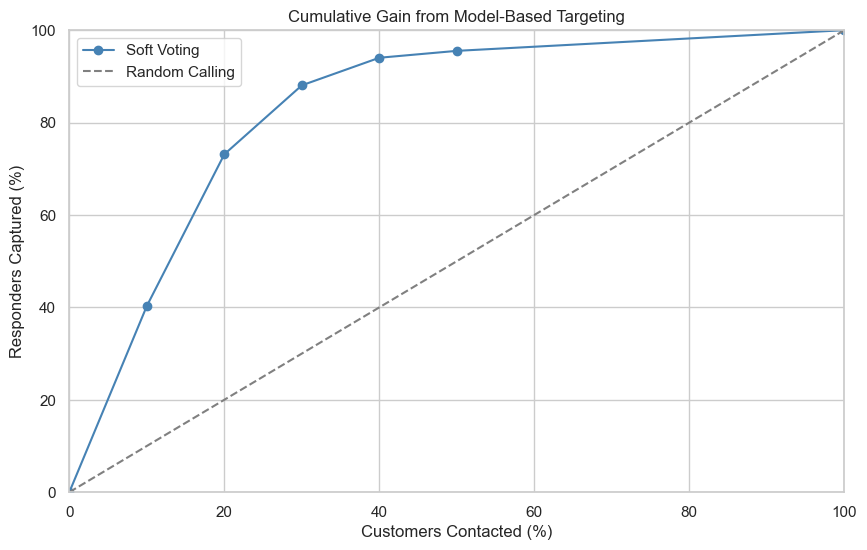

In [43]:
contact_percentages = [0] + campaign_summary["Customers Contacted (%)"].tolist() + [100]
capture_percentages = [0] + campaign_summary["Responders Captured (%)"].tolist() + [100]

plt.figure(figsize=(10, 6))
plt.plot(contact_percentages, capture_percentages, marker="o", color=PLOT_COLOR, label="Soft Voting")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Random Calling")
plt.title("Cumulative Gain from Model-Based Targeting")
plt.xlabel("Customers Contacted (%)")
plt.ylabel("Responders Captured (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.show()

### Recommended calling strategy

- Begin with the top 20% of customers ranked by the model. On the test data, this group captures about 73% of responders and produces a response rate of 54.4%.
- If the business can support more calls, contacting the top 30% captures about 88% of responders while retaining a lift of approximately 2.94 over random calling.
- Use the probability ranking instead of treating every prediction above 0.50 as the only valid target.
- Give priority to customers showing the strongest observed signals: higher historical spending, catalog activity, recent purchases, and longer tenure.
- Run a controlled pilot before full deployment. Compare a model-selected group with a randomly selected control group to measure whether targeting creates incremental sales.

### Measuring the value of the model

The main operational measures should be:

- **Lift:** Response rate among targeted customers divided by the overall response rate.
- **Responder capture:** Percentage of all responders found within the selected calling group.
- **Cost per conversion:** Total campaign cost divided by completed membership sales.
- **Incremental profit:** Additional conversions caused by the campaign multiplied by the net value of each membership, less calling costs.

The next calculation illustrates the value of targeting the top 20% compared with randomly calling the same number of customers. The $499 figure represents membership revenue, not profit.

In [44]:
top_20_percent = campaign_summary[campaign_summary["Customers Contacted (%)"] == 20].iloc[0]

random_expected_responders = top_20_percent["Customers Called"] * baseline_response_rate
additional_responders = top_20_percent["Responders Found"] - random_expected_responders
additional_membership_revenue = additional_responders * 499

value_example = pd.Series({
    "Customers called": top_20_percent["Customers Called"],
    "Responders found using the model": top_20_percent["Responders Found"],
    "Expected responders from random calling": random_expected_responders,
    "Additional responders": additional_responders,
    "Additional membership revenue at $499": additional_membership_revenue,
})

display(value_example.round(2).to_frame("Top 20% Test Sample"))

,Top 20% Test Sample
Customers called,90.00
Responders found using the model,49.00
Expected responders from random calling,13.46
Additional responders,35.54
Additional membership revenue at $499,17734.55


In the test sample, model-based targeting finds about 36 more responders than random selection among the same 90 calls. This corresponds to approximately $17,735 in additional membership revenue before call costs, discount costs, and other expenses.

For deployment, ABC should replace membership revenue with the expected net contribution per sale. A customer should generally be contacted when the expected value of calling exceeds the cost of the call. Performance should be tracked by campaign period, customer segment, and score band, with the model retrained when response patterns change.

## 10. Conclusion

The historical campaign response is imbalanced, with only about 15% of customers accepting the offer. Spending, catalog purchases, recency, household composition, income, and customer tenure are among the strongest observed predictors.

Gradient boosting was the strongest individual tuned model. Combining it with logistic regression and random forest through soft voting improves the cross-validated PR AUC to 0.549. On the test set, soft voting achieves recall of 0.761, F1 score of 0.630, ROC AUC of 0.907, and PR AUC of 0.624.

The probability ranking can make the campaign more efficient: the top 20% of customers contains about 73% of observed responders. ABC should use the model as a prioritization tool, begin with a controlled pilot, and select the final contact threshold using call capacity and expected profit. Because the data comes from a historical campaign, the estimated lift should be validated on new customers before full deployment.